In [ ]:
from google.colab import drive
import pathlib, os, torch

drive.mount('/content/drive')
ROOT = pathlib.Path('/content/drive/MyDrive/stock_project')
os.chdir(ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not found. Using CPU.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
GPU: Tesla T4


In [ ]:
!pip install -q pytorch-lightning yfinance pandas-ta seaborn tqdm
import torch, pandas, numpy

print("torch:", torch.__version__)
print("pandas:", pandas.__version__)
print("numpy:", numpy.__version__)
print("All good.")

torch: 2.10.0+cu128
pandas: 3.0.1
numpy: 2.2.6
All good.


In [ ]:
import os
from pathlib import Path

if not Path('/content/stocknet-dataset/price/raw').exists():
    print("Cloning StockNet...")
    os.system("apt-get install -y git-lfs")
    os.system("git lfs install")
    os.system("git clone https://github.com/yumoxu/stocknet-dataset.git /content/stocknet-dataset")
    print("Done.")
else:
    print("Already available.")

print("Price tickers:", len(os.listdir('/content/stocknet-dataset/price/raw')))

Already available.
Price tickers: 88


In [ ]:
### NB4 Cell 4 — Price preprocessing (Version-Agnostic) ###
import pandas as pd
import numpy as np
import torch
import pandas_ta as ta
from sklearn.preprocessing import StandardScaler
from pathlib import Path
from tqdm import tqdm

PRICE_DIR = Path('/content/stocknet-dataset/price/raw')
PROC_DIR  = ROOT / 'data/stocknet/processed'
PROC_DIR.mkdir(parents=True, exist_ok=True)
WINDOW = 10

FEATS = ['Open','High','Low','Close','Volume',
         'rsi','macd','macd_sig','bb_h','bb_l','bb_w','log_ret']

def add_indicators(df):
    df = df.copy()

    # RSI
    df['rsi'] = ta.rsi(df['Close'], length=14)

    # MACD returns [MACD, Histogram, Signal]
    macd = ta.macd(df['Close'], fast=12, slow=26, signal=9)
    df['macd']     = macd.iloc[:, 0]
    df['macd_sig'] = macd.iloc[:, 2]

    # BBANDS returns [Lower, Mid, Upper, Bandwidth, Percent]
    bb = ta.bbands(df['Close'], length=5, std=2.0)
    df['bb_l']     = bb.iloc[:, 0]
    df['bb_h']     = bb.iloc[:, 2]
    df['bb_w']     = bb.iloc[:, 3]

    df['log_ret']  = np.log(df['Close'] / df['Close'].shift(1))
    return df.dropna()

X_tr, y_tr = [], []
X_va, y_va = [], []
X_te, y_te = [], []

csv_files = sorted(PRICE_DIR.iterdir())
print(f"Processing {len(csv_files)} tickers...")

for csv_file in tqdm(csv_files):
    try:
        df = pd.read_csv(csv_file, index_col=0, parse_dates=True)
        df.columns = [c.strip() for c in df.columns]
        if 'Adj Close' in df.columns:
            df = df.drop(columns=['Adj Close'])

        df = add_indicators(df)
        if len(df) < WINDOW + 10:
            continue

        n  = len(df)
        t1 = int(n * 0.79)
        t2 = int(n * 0.87)
        scaler = StandardScaler()

        X_all  = np.zeros((n, len(FEATS)))
        X_all[:t1] = scaler.fit_transform(df[FEATS].values[:t1])
        X_all[t1:] = scaler.transform(df[FEATS].values[t1:])
        closes = df['Close'].values
        y_all  = np.zeros(n)

        for i in range(n - 1):
            y_all[i] = 1 if closes[i+1] > closes[i] else 0

        for i in range(WINDOW, n - 1):
            x_win = X_all[i-WINDOW:i]
            y_val = y_all[i]
            if   i < t1: X_tr.append(x_win); y_tr.append(y_val)
            elif i < t2: X_va.append(x_win); y_va.append(y_val)
            else:        X_te.append(x_win); y_te.append(y_val)

    except Exception as e:
        print(f"Skipping {csv_file.name}: {e}")
        continue

for name, arr in [('X_train',X_tr),('y_train',y_tr),
                   ('X_val',X_va),  ('y_val',y_va),
                   ('X_test',X_te), ('y_test',y_te)]:
    t = torch.tensor(np.array(arr), dtype=torch.float32)
    torch.save(t, PROC_DIR / f"{name}.pt")
    print(f"{name}: {t.shape}")

print("\nPreprocessing complete.")

Processing 88 tickers...


100%|██████████| 88/88 [00:05<00:00, 15.13it/s]


X_train: torch.Size([82536, 10, 12])
y_train: torch.Size([82536])
X_val: torch.Size([8456, 10, 12])
y_val: torch.Size([8456])
X_test: torch.Size([13713, 10, 12])
y_test: torch.Size([13713])

Preprocessing complete.


In [ ]:
### NB4 Cell 5 — Define LSTM and GRU model ###
import torch.nn as nn

class RecurrentModel(nn.Module):
    def __init__(self, cell='lstm', inp=12, hid=128,
                 layers=2, drop=0.3):
        super().__init__()
        RNN = nn.LSTM if cell == 'lstm' else nn.GRU
        self.rnn = RNN(inp, hid, layers,
                       dropout=drop, batch_first=True)
        self.fc = nn.Sequential(
            nn.Dropout(drop),
            nn.Linear(hid, 1),
            nn.Sigmoid()
        )
    def forward(self, x):
        out, _ = self.rnn(x)
        return self.fc(out[:, -1, :]).squeeze(-1)

print("RecurrentModel defined.")

RecurrentModel defined.


In [ ]:
### NB4 Cell 6 — Define TFT (manual PyTorch) ###
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleTFT(nn.Module):
    def __init__(self, input_size=12, model_dim=64,
                 num_heads=4, dropout=0.1, seq_len=10):
        super().__init__()
        self.input_size = input_size
        self.model_dim  = model_dim
        self.seq_len    = seq_len

        self.var_select = nn.Sequential(
            nn.Linear(input_size, input_size),
            nn.Softmax(dim=-1)
        )

        self.input_proj = nn.Linear(input_size, model_dim)

        self.attn = nn.MultiheadAttention(
            embed_dim=model_dim,
            num_heads=num_heads,
            dropout=dropout,
            batch_first=True
        )
        self.attn_norm = nn.LayerNorm(model_dim)

        self.ff = nn.Sequential(
            nn.Linear(model_dim, model_dim * 4),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(model_dim * 4, model_dim)
        )
        self.ff_norm = nn.LayerNorm(model_dim)

        self.dropout = nn.Dropout(dropout)
        self.fc      = nn.Linear(model_dim, 1)

        self.last_attn_weights  = None
        self.last_var_weights   = None

    def forward(self, x):
        var_weights = self.var_select(x.mean(dim=1))
        self.last_var_weights = var_weights.detach().cpu()

        x = x * var_weights.unsqueeze(1)
        x = self.input_proj(x)

        attn_out, attn_weights = self.attn(x, x, x)
        self.last_attn_weights = attn_weights.detach().cpu()
        x = self.attn_norm(x + attn_out)

        x = self.ff_norm(x + self.ff(x))

        x = x.mean(dim=1)
        x = self.dropout(x)
        return torch.sigmoid(self.fc(x)).squeeze(-1)

    def get_feature_importance(self):
        if self.last_var_weights is None:
            return None
        return self.last_var_weights.mean(dim=0).numpy()

print("SimpleTFT defined.")

SimpleTFT defined.


In [ ]:
### NB4 Cell 7 — Training function ###
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import f1_score

def train_model(model, save_path, model_name="model",
                epochs=50, patience=7, lr=1e-3, batch_size=64):
    print(f"\nTraining {model_name}...")

    X_tr = torch.load(PROC_DIR / 'X_train.pt')
    y_tr = torch.load(PROC_DIR / 'y_train.pt')
    X_va = torch.load(PROC_DIR / 'X_val.pt')
    y_va = torch.load(PROC_DIR / 'y_val.pt')

    model   = model.to(device)
    opt     = torch.optim.Adam(model.parameters(), lr=lr)
    sched   = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)
    loss_fn = nn.BCELoss()

    tr_dl = DataLoader(
        TensorDataset(X_tr.to(device), y_tr.to(device)),
        batch_size=batch_size, shuffle=True)
    va_dl = DataLoader(
        TensorDataset(X_va.to(device), y_va.to(device)),
        batch_size=256)

    best_loss, no_imp = float('inf'), 0
    history = []

    for ep in range(epochs):
        model.train()
        train_loss = 0
        for xb, yb in tr_dl:
            opt.zero_grad()
            loss = loss_fn(model(xb), yb)
            loss.backward()
            opt.step()
            train_loss += loss.item()
        sched.step()
        train_loss /= len(tr_dl)

        model.eval()
        val_loss, all_preds, all_true = 0, [], []
        with torch.no_grad():
            for xb, yb in va_dl:
                preds = model(xb)
                val_loss += loss_fn(preds, yb).item()
                all_preds.extend((preds >= 0.5).cpu().numpy())
                all_true.extend(yb.cpu().numpy())
        val_loss /= len(va_dl)
        val_f1 = f1_score(all_true, all_preds, average='macro', zero_division=0)

        history.append({'epoch':ep+1,'train_loss':train_loss,
                        'val_loss':val_loss,'val_f1':val_f1})
        print(f"  ep {ep+1:3d} | train={train_loss:.4f} val={val_loss:.4f} f1={val_f1:.4f}", end='\r')

        if val_loss < best_loss:
            best_loss = val_loss
            torch.save(model.state_dict(), save_path)
            no_imp = 0
        else:
            no_imp += 1
            if no_imp >= patience:
                print(f"\n  Early stop at epoch {ep+1}")
                break

    print(f"\n{model_name} done. Best val loss: {best_loss:.4f}")
    print(f"Saved to {save_path}")
    return history

print("Training function defined.")

Training function defined.


In [ ]:
### NB4 Cell 8 — Train LSTM ###
(ROOT / 'models/lstm').mkdir(parents=True, exist_ok=True)
lstm_model   = RecurrentModel('lstm')
lstm_history = train_model(
    lstm_model,
    save_path=ROOT / 'models/lstm/best.pt',
    model_name='LSTM'
)
torch.cuda.empty_cache()


Training LSTM...
  ep  10 | train=0.6822 val=0.6985 f1=0.4934
  Early stop at epoch 10

LSTM done. Best val loss: 0.6934
Saved to /content/drive/MyDrive/stock_project/models/lstm/best.pt


In [ ]:
### NB4 Cell 9 — Train GRU ###
(ROOT / 'models/gru').mkdir(parents=True, exist_ok=True)
gru_model   = RecurrentModel('gru')
gru_history = train_model(
    gru_model,
    save_path=ROOT / 'models/gru/best.pt',
    model_name='GRU'
)
torch.cuda.empty_cache()


Training GRU...
  ep  10 | train=0.6777 val=0.7028 f1=0.5003
  Early stop at epoch 10

GRU done. Best val loss: 0.6933
Saved to /content/drive/MyDrive/stock_project/models/gru/best.pt


In [ ]:

(ROOT / 'models/tft').mkdir(parents=True, exist_ok=True)
tft_model   = SimpleTFT()
tft_history = train_model(
    tft_model,
    save_path=ROOT / 'models/tft/best.pt',
    model_name='TFT',
    batch_size=32
)
torch.cuda.empty_cache()


Training TFT...
  ep  16 | train=0.6908 val=0.6948 f1=0.5067
  Early stop at epoch 16

TFT done. Best val loss: 0.6927
Saved to /content/drive/MyDrive/stock_project/models/tft/best.pt


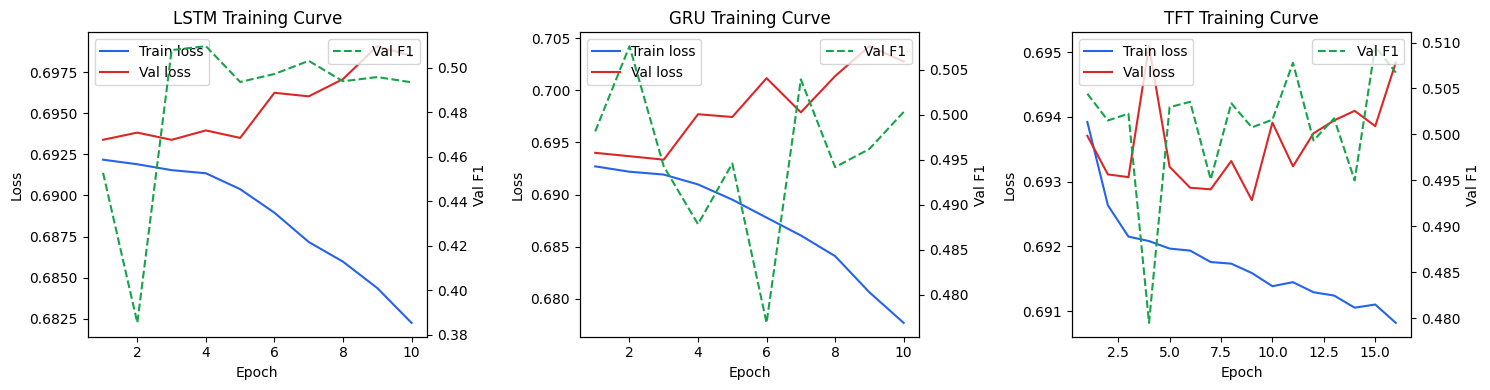

Training curves saved.


In [ ]:

import json
import matplotlib.pyplot as plt

(ROOT / 'outputs/figures').mkdir(parents=True, exist_ok=True)

# Save histories
histories = {'lstm': lstm_history, 'gru': gru_history, 'tft': tft_history}
(ROOT / 'outputs/training_histories.json').write_text(json.dumps(histories))

# Plot loss curves
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, hist) in zip(axes, histories.items()):
    epochs     = [h['epoch']     for h in hist]
    train_loss = [h['train_loss'] for h in hist]
    val_loss   = [h['val_loss']   for h in hist]
    val_f1     = [h['val_f1']     for h in hist]

    ax.plot(epochs, train_loss, label='Train loss', color='#2563EB')
    ax.plot(epochs, val_loss,   label='Val loss',   color='#DC2626')
    ax2 = ax.twinx()
    ax2.plot(epochs, val_f1, label='Val F1', color='#16A34A', linestyle='--')

    ax.set_title(f'{name.upper()} Training Curve')
    ax.set_xlabel('Epoch')
    ax.set_ylabel('Loss')
    ax2.set_ylabel('Val F1')
    ax.legend(loc='upper left')
    ax2.legend(loc='upper right')

plt.tight_layout()
plt.savefig(ROOT / 'outputs/figures/training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Training curves saved.")

In [ ]:

PROC_DIR = ROOT / 'data/stocknet/processed'
X_va = torch.load(PROC_DIR / 'X_val.pt')
sample = X_va[:4].to(device)

for name, ModelClass, ckpt in [
    ('LSTM', lambda: RecurrentModel('lstm'), ROOT/'models/lstm/best.pt'),
    ('GRU',  lambda: RecurrentModel('gru'),  ROOT/'models/gru/best.pt'),
    ('TFT',  SimpleTFT,                      ROOT/'models/tft/best.pt'),
]:
    m = ModelClass().to(device)
    m.load_state_dict(torch.load(ckpt, map_location=device))
    m.eval()
    with torch.no_grad():
        out = m(sample)
    size = ckpt.stat().st_size / 1e6
    print(f"{name}: {size:.1f}MB | sample preds: {out.cpu().numpy().round(3)}")

print("\nAll 3 models verified.")

LSTM: 0.8MB | sample preds: [0.493 0.493 0.494 0.494]
GRU: 0.6MB | sample preds: [0.491 0.492 0.494 0.493]
TFT: 0.2MB | sample preds: [0.492 0.492 0.493 0.494]

All 3 models verified.
